Downloading the dataset and installing necessary imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/heart_disease/heart_cleveland_upload.csv')

Printing the rows and columns

In [ ]:
print(df.shape)
print(df.head())

(297, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


Correlation Heatmap

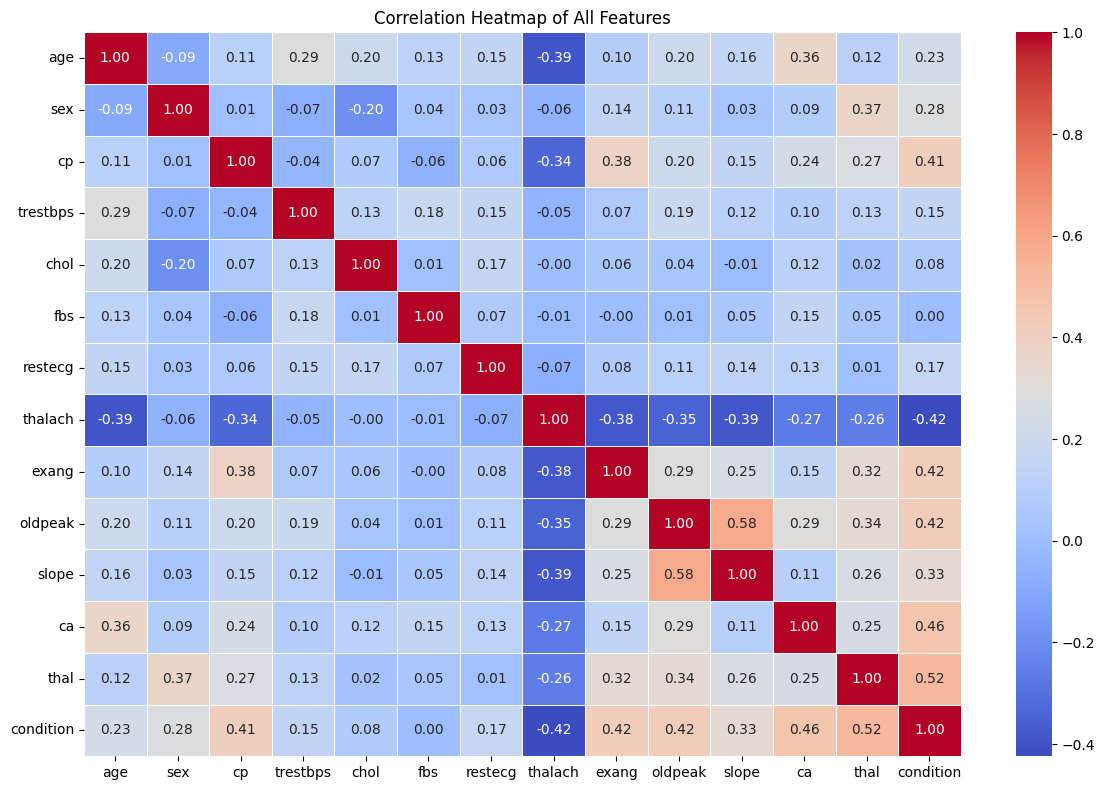

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

How age distributes across sick vs healthy patients

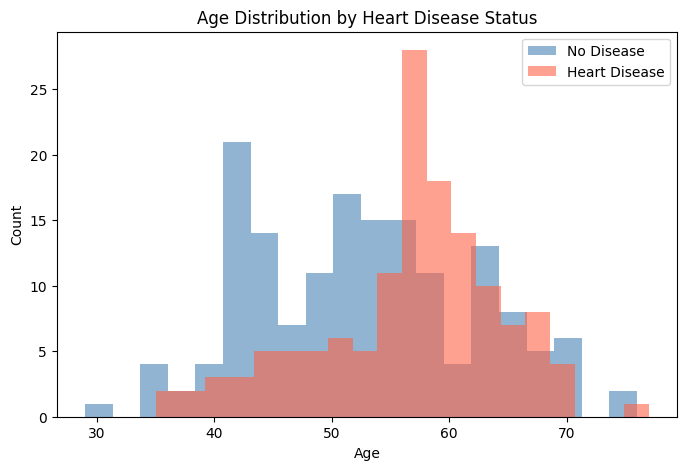

In [ ]:
plt.figure(figsize=(8, 5))
df[df['condition']==0]['age'].plot(kind='hist', alpha=0.6, label='No Disease', bins=20, color='steelblue')
df[df['condition']==1]['age'].plot(kind='hist', alpha=0.6, label='Heart Disease', bins=20, color='tomato')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

Preprocessing and building the models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('condition', axis=1)
y = df['condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (237, 13)
Test set: (60, 13)


Train all three models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    pred = model.predict(X_test_scaled)
    print(f"{name}: {accuracy_score(y_test, pred)*100:.2f}%")

Logistic Regression: 73.33%
Random Forest: 70.00%
XGBoost: 68.33%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:40:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Cross Validation(It splits the 297 patients into 5 equal groups of roughly 60 patients each. Then it runs 5 separate experiments)

In [ ]:
from sklearn.model_selection import cross_val_score

for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 80.51% (+/- 10.54%)
Random Forest: 74.10% (+/- 14.26%)
XGBoost: 68.71% (+/- 13.85%)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:40:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:40:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:40:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:40:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Fixes all warnings and tunes Random Forest

In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Fixes Logistic Regression by raising max_iter to 5000(fully converges)
lr = LogisticRegression(max_iter=5000)

# Fix XGBoost warning remove deprecated parameter
xgb = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)

# systematically tests 36 different combinations of settings
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

rf_tuned = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Compare all models with cross-validation
print("\n--- Cross-Validation Results (5-fold) ---")
for name, model in [('Logistic Regression', lr), ('Random Forest (tuned)', rf_tuned), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

Best parameters: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}

--- Cross-Validation Results (5-fold) ---
Logistic Regression: 80.51% (+/- 10.54%)
Random Forest (tuned): 75.43% (+/- 13.89%)
XGBoost: 68.71% (+/- 13.85%)


 Generate all your evaluation visuals in one go

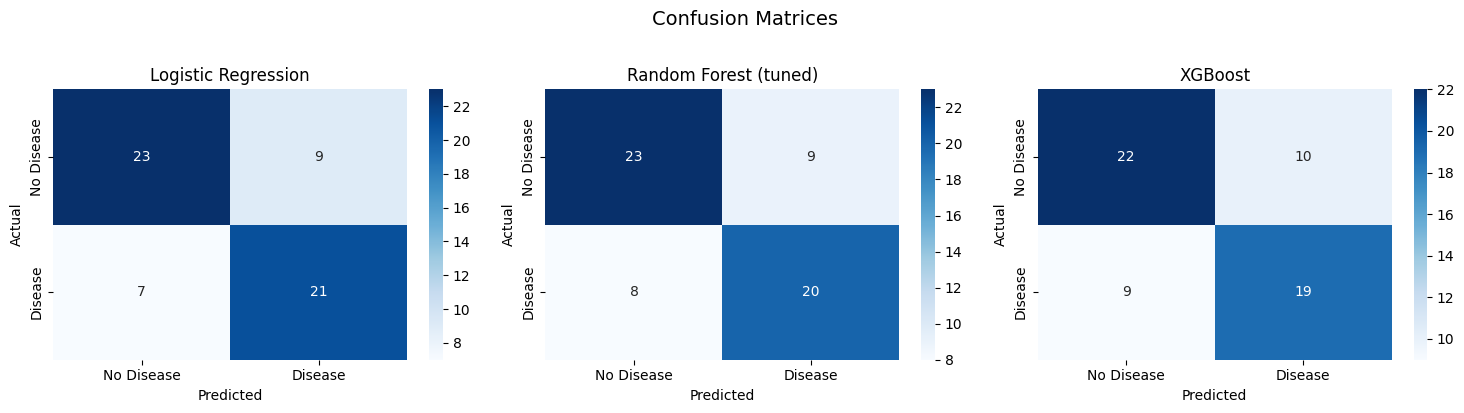

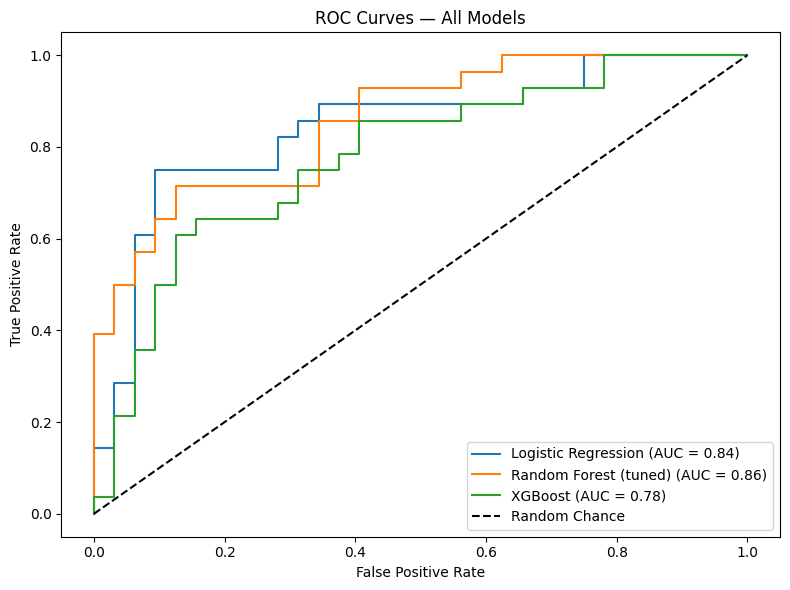

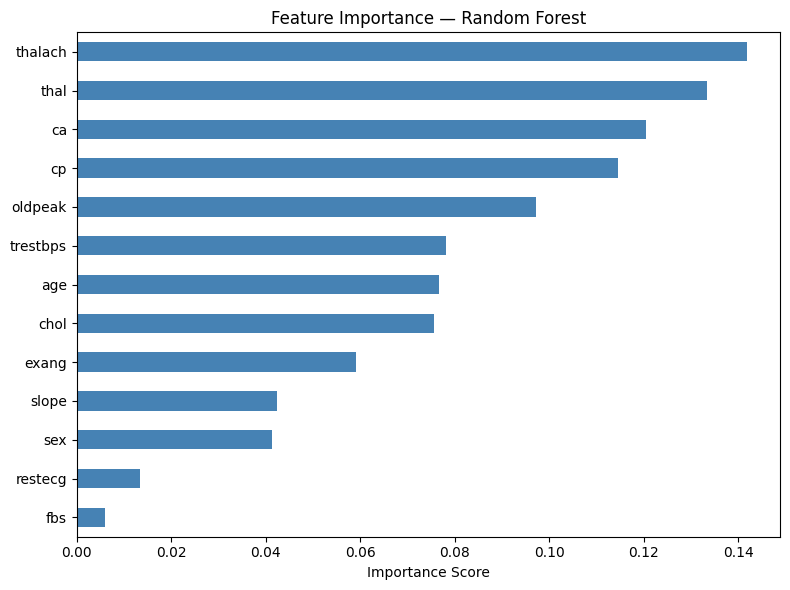

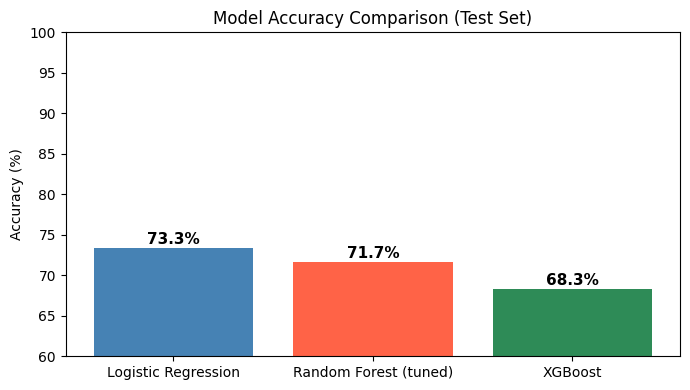


 Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.77      0.72      0.74        32
     Disease       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60


 Random Forest (tuned)
              precision    recall  f1-score   support

  No Disease       0.74      0.72      0.73        32
     Disease       0.69      0.71      0.70        28

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60


 XGBoost
              precision    recall  f1-score   support

  No Disease       0.71      0.69      0.70        32
     Disease       0.66      0.68      0.67        28

    accuracy                           0.68        60
   macro avg       0.68      0.68      0.68        60
weighted avg      

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Refit all models on training data
lr.fit(X_train_scaled, y_train)
rf_tuned.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

models = [('Logistic Regression', lr), ('Random Forest (tuned)', rf_tuned), ('XGBoost', xgb)]

#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#ROC curves
plt.figure(figsize=(8, 6))
for name, model in models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

#Feature importance (Random Forest)
feat_imp = pd.Series(rf_tuned.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#Model accuracy comparison
accuracies = {name: accuracy_score(y_test, model.predict(X_test_scaled)) * 100
              for name, model in models}
plt.figure(figsize=(7, 4))
plt.bar(accuracies.keys(), accuracies.values(), color=['steelblue', 'tomato', 'seagreen'])
plt.ylim(60, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison (Test Set)')
for i, (k, v) in enumerate(accuracies.items()):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

#Print classification reports
for name, model in models:
    print(f"\n{'='*45}")
    print(f" {name}")
    print('='*45)
    print(classification_report(y_test, model.predict(X_test_scaled),
                                 target_names=['No Disease', 'Disease']))

In [ ]:
#import joblib

# Save the Logistic Regression model
#joblib.dump(lr, 'heart_disease_model.pkl')
#joblib.dump(scaler, 'scaler.pkl')

#from google.colab import files
#files.download('heart_disease_model.pkl')
#files.download('scaler.pkl')